# AI013 - Time Series Forecasting
**Phoenix Project | AI-ML Team**

Forecasting future hazard severity scores using historical disaster event data.

---

**Steps covered:**
1. Prepare time-based dataset
2. Create sequential inputs
3. Train forecasting model
4. Generate future predictions
5. Analyse trend behaviour
6. Compare predictions vs actual

**Dataset:** `synthetic/data/parent_disaster_dataset.csv` — 58 timestamped hazard events across Australia

> Note: dataset has 58 records which is small for deep learning. A lightweight 1-layer LSTM is used to avoid overfitting. A rolling mean baseline is included for comparison.

In [1]:
# !pip install pandas numpy scikit-learn torch matplotlib seaborn

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device} | torch: {torch.__version__}')

device: cpu | torch: 2.11.0


---
## Step 1 - Prepare Time-Based Dataset

In [3]:
BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

DISASTER_CSV = os.path.join(BASE, 'synthetic', 'data', 'parent_disaster_dataset.csv')
MASTER_CSV   = os.path.join(BASE, 'synthetic', 'data', 'master_ai005_dataset.csv')
AI004_CSV    = os.path.join(BASE, 'features', 'ai004_features_output.csv')

for label, path in [('parent_disaster', DISASTER_CSV), ('master_ai005', MASTER_CSV), ('ai004_features', AI004_CSV)]:
    print(f'{label}: {"OK" if os.path.exists(path) else "NOT FOUND"}')

parent_disaster: OK
master_ai005: OK
ai004_features: OK


In [4]:
df_raw = pd.read_csv(DISASTER_CSV)
print(f'shape: {df_raw.shape}')
df_raw.head()

shape: (58, 18)


,hazard_event_id,integration_id,state,region,suburb,event_type,severity_score,severity_level,risk_category,start_time,duration_hours,temperature_c,rainfall_mm,humidity_pct,fatalities,injuries,economic_loss_million,affected_population
0,HZ_00001,eeb92602-6fe0-4ebb-819d-f7c443896216,Victoria,Melbourne Metro,Melbourne,bushfire,3.7,medium,low,2025-02-18T00:00:00+00:00,12,40.1,1.7,12.9,3,38,146.58,370
1,HZ_00002,8810dcdc-4ed9-4860-99b9-a39d6e839092,Victoria,Melbourne Metro,Melbourne,heatwave,5.9,medium,medium,2024-05-23T00:00:00+00:00,6,51.2,0.0,10.3,15,37,103.78,590
2,HZ_00003,a5ad271c-f785-436b-818d-c45ec803da53,Victoria,Melbourne Metro,Melbourne,flood,4.6,medium,low,2024-07-12T00:00:00+00:00,72,23.9,81.5,87.8,12,59,15.15,459
3,HZ_00004,08501bb6-1113-47f8-9c7f-7bde0e085169,New South Wales,Hunter Region,Newcastle,flood,8.0,high,high,2025-08-10T00:00:00+00:00,24,23.0,101.5,71.1,17,112,44.47,800
4,HZ_00005,2ac6f328-9cfc-45db-b447-dacf947438b5,New South Wales,Greater Sydney,Parramatta,bushfire,5.0,medium,medium,2024-10-06T00:00:00+00:00,48,37.0,1.2,NaN,18,99,17.31,500


In [5]:
df_raw['start_time'] = pd.to_datetime(df_raw['start_time'], utc=True)
df = df_raw.sort_values('start_time').reset_index(drop=True)

FEATURE_COLS = [
    'temperature_c',
    'rainfall_mm',
    'humidity_pct',
    'duration_hours',
    'fatalities',
    'injuries',
    'economic_loss_million',
    'affected_population'
]
TARGET = 'severity_score'

df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
df[TARGET]       = df[TARGET].fillna(df[TARGET].median())

print(f'{len(df)} events | {df["start_time"].min().date()} to {df["start_time"].max().date()}')
print(f'nulls remaining: {df[FEATURE_COLS + [TARGET]].isnull().sum().sum()}')

58 events | 2024-01-02 to 2025-12-17
nulls remaining: 0


In [6]:
print(df[TARGET].describe().round(2))
print()
print(df['event_type'].value_counts())

count    58.00
mean      6.08
std       2.16
min       2.10
25%       4.53
50%       5.50
75%       7.75
max      10.00
Name: severity_score, dtype: float64

event_type
bushfire      19
storm         17
flood          9
heatwave       8
earthquake     3
cyclone        2
Name: count, dtype: int64


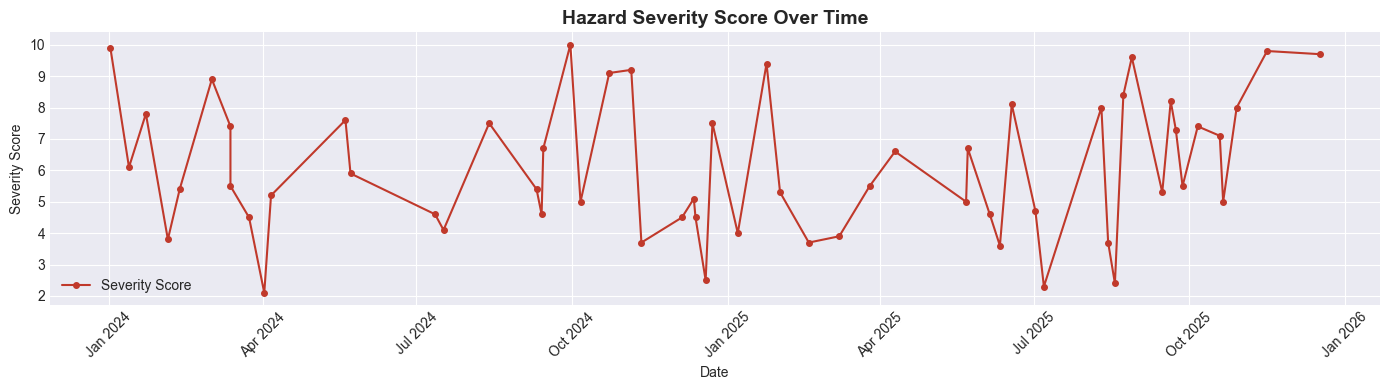

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['start_time'], df[TARGET], marker='o', markersize=4,
        linewidth=1.5, color='#c0392b', label='Severity Score')
ax.set_title('Hazard Severity Score Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Severity Score')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('severity_over_time.png', dpi=150)
plt.show()

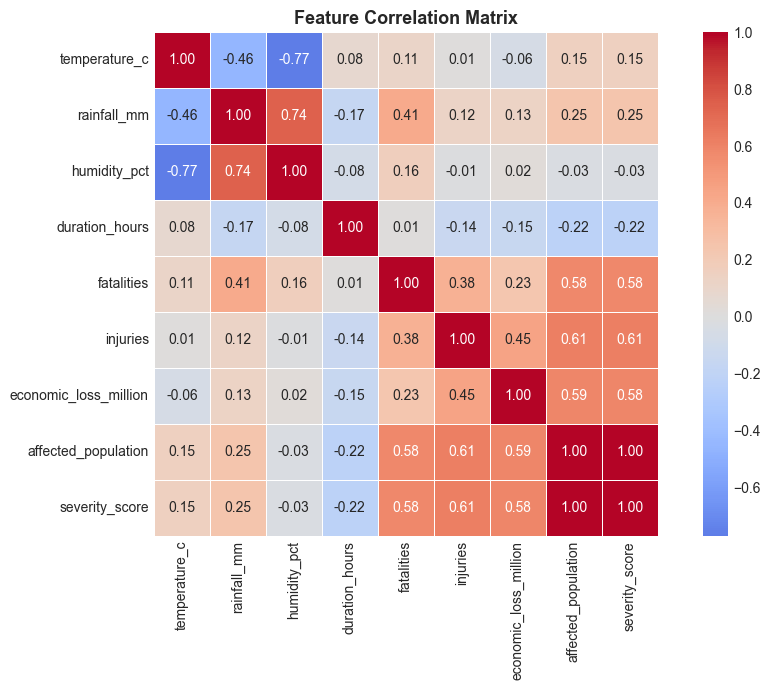

In [8]:
corr = df[FEATURE_COLS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

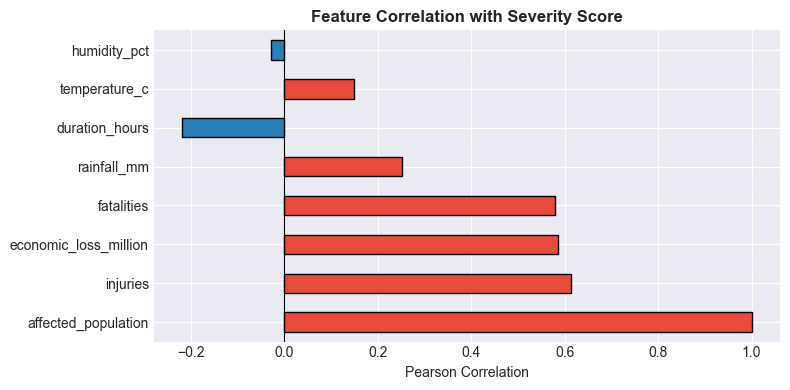

In [9]:
severity_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colours = ['#e74c3c' if v > 0 else '#2980b9' for v in severity_corr]
severity_corr.plot(kind='barh', ax=ax, color=colours, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Severity Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150)
plt.show()

---
## Step 2 - Create Sequential Inputs

Sliding window of 5 past events → predict the next severity score.

In [10]:
feat_scaler   = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feat_scaler.fit_transform(df[FEATURE_COLS])
y_scaled = target_scaler.fit_transform(df[[TARGET]])

print(f'features: {X_scaled.shape} | target: {y_scaled.shape}')

features: (58, 8) | target: (58, 1)


In [11]:
WINDOW = 5

def make_sequences(features, target, window):
    """Sliding window: each X is `window` past rows, y is the next value."""
    X_out, y_out = [], []
    for i in range(len(features) - window):
        X_out.append(features[i : i + window])
        y_out.append(target[i + window])
    return np.array(X_out), np.array(y_out)


X_seq, y_seq = make_sequences(X_scaled, y_scaled, WINDOW)
print(f'sequences → X: {X_seq.shape}  y: {y_seq.shape}')

sequences → X: (53, 5, 8)  y: (53, 1)


In [12]:
TRAIN_SPLIT = 0.80
split = int(len(X_seq) * TRAIN_SPLIT)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

# shuffle=False keeps the time order intact
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=8, shuffle=False)

print(f'train: {len(X_train)} | test: {len(X_test)}')

train: 42 | test: 11


---
## Step 3 - Train Forecasting Model

Using a single-layer LSTM — kept lightweight because dataset only has 58 records. A rolling mean baseline is trained alongside for comparison.

In [13]:
class LSTMForecaster(nn.Module):
    """
    Lightweight single-layer LSTM for small datasets.
    Input: (batch, window, features) -> Output: (batch, 1)
    """
    def __init__(self, input_size, hidden_size=32, dropout=0.1):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))


INPUT_SIZE  = len(FEATURE_COLS)
HIDDEN_SIZE = 32
EPOCHS      = 200
LR          = 0.001

model     = LSTMForecaster(INPUT_SIZE, HIDDEN_SIZE).to(device)
loss_fn   = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=20, factor=0.5)

print(model)
print(f'trainable params: {sum(p.numel() for p in model.parameters()):,}')

# --- training ---
train_losses, val_losses = [], []
best_val, best_weights   = float('inf'), None

print(f'\ntraining on {device} for {EPOCHS} epochs...\n')

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimiser.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        batch_losses.append(loss.item())

    avg_train = np.mean(batch_losses)
    train_losses.append(avg_train)

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_test_t.to(device)), y_test_t.to(device)).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val     = val_loss
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch == 1 or epoch % 50 == 0:
        print(f'epoch {epoch:3d}  train: {avg_train:.5f}  val: {val_loss:.5f}')

model.load_state_dict(best_weights)
print(f'\nbest val loss: {best_val:.5f}')

LSTMForecaster(
  (lstm): LSTM(8, 32, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
trainable params: 5,409

training on cpu for 200 epochs...

epoch   1  train: 0.33724  val: 0.53257
epoch  50  train: 0.08586  val: 0.09705
epoch 100  train: 0.07969  val: 0.10530
epoch 150  train: 0.07196  val: 0.10652
epoch 200  train: 0.07053  val: 0.10653

best val loss: 0.05838


In [14]:
baseline_preds_scaled = np.array([
    y_scaled[split + i - WINDOW : split + i].mean()
    for i in range(len(X_test))
]).reshape(-1, 1)

baseline_preds = target_scaler.inverse_transform(baseline_preds_scaled)
print('baseline ready')

baseline ready


In [15]:
os.makedirs('checkpoints', exist_ok=True)
torch.save({
    'model_state'  : best_weights,
    'input_size'   : INPUT_SIZE,
    'hidden_size'  : HIDDEN_SIZE,
    'window'       : WINDOW,
    'feature_cols' : FEATURE_COLS,
    'target_col'   : TARGET
}, 'checkpoints/ai013_lstm_best.pt')
print('model saved → checkpoints/ai013_lstm_best.pt')

model saved → checkpoints/ai013_lstm_best.pt


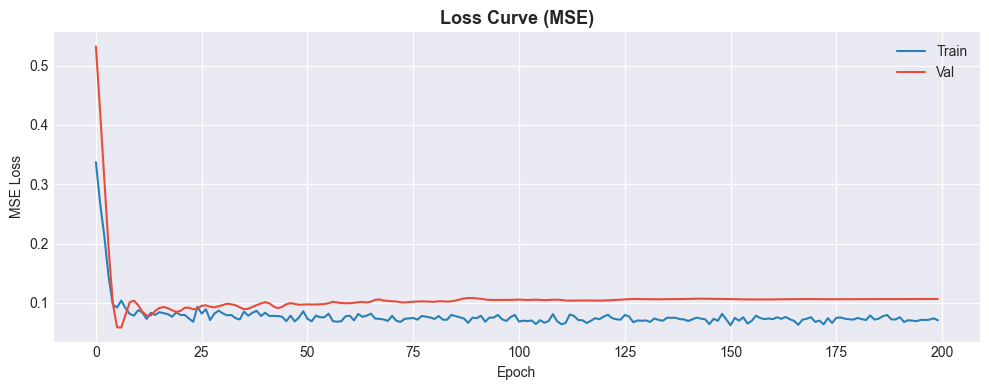

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train', color='#2980b9', linewidth=1.5)
ax.plot(val_losses,   label='Val',   color='#e74c3c', linewidth=1.5)
ax.set_title('Loss Curve (MSE)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

---
## Step 4 - Generate Future Predictions

In [17]:
model.eval()
with torch.no_grad():
    test_pred_scaled = model(X_test_t.to(device)).cpu().numpy()

test_pred_actual = target_scaler.inverse_transform(test_pred_scaled)
y_test_actual    = target_scaler.inverse_transform(y_test)

print('predicted vs actual (test set):')
for i in range(len(test_pred_actual)):
    print(f'  pred {test_pred_actual[i][0]:.2f}  |  actual {y_test_actual[i][0]:.2f}')

predicted vs actual (test set):
  pred 6.39  |  actual 9.60
  pred 6.62  |  actual 5.30
  pred 6.48  |  actual 8.20
  pred 6.76  |  actual 7.30
  pred 6.94  |  actual 5.50
  pred 6.84  |  actual 7.40
  pred 6.60  |  actual 7.10
  pred 6.52  |  actual 5.00
  pred 6.17  |  actual 8.00
  pred 6.65  |  actual 9.80
  pred 7.13  |  actual 9.70


In [18]:
FUTURE_STEPS = 7

def forecast_ahead(model, seed_window, steps, device):
    """Multi-step forecast: each prediction feeds back as next input."""
    model.eval()
    preds, window = [], seed_window.copy()
    with torch.no_grad():
        for _ in range(steps):
            inp      = torch.tensor(window[np.newaxis], dtype=torch.float32).to(device)
            p        = model(inp).cpu().numpy()[0][0]
            preds.append(p)
            next_row    = window[-1].copy()
            next_row[0] = p
            window      = np.vstack([window[1:], next_row])
    return np.array(preds)


future_scaled = forecast_ahead(model, X_scaled[-WINDOW:], FUTURE_STEPS, device)
future_actual = target_scaler.inverse_transform(future_scaled.reshape(-1, 1))

last_date    = df['start_time'].max()
future_dates = pd.date_range(start=last_date, periods=FUTURE_STEPS + 1, freq='W')[1:]

future_df = pd.DataFrame({
    'date'              : future_dates,
    'predicted_severity': future_actual.flatten()
})
print(future_df.to_string(index=False))

                     date  predicted_severity
2025-12-28 00:00:00+00:00            7.401087
2026-01-04 00:00:00+00:00            7.528867
2026-01-11 00:00:00+00:00            7.671041
2026-01-18 00:00:00+00:00            7.634332
2026-01-25 00:00:00+00:00            7.534822
2026-02-01 00:00:00+00:00            7.511528
2026-02-08 00:00:00+00:00            7.511104


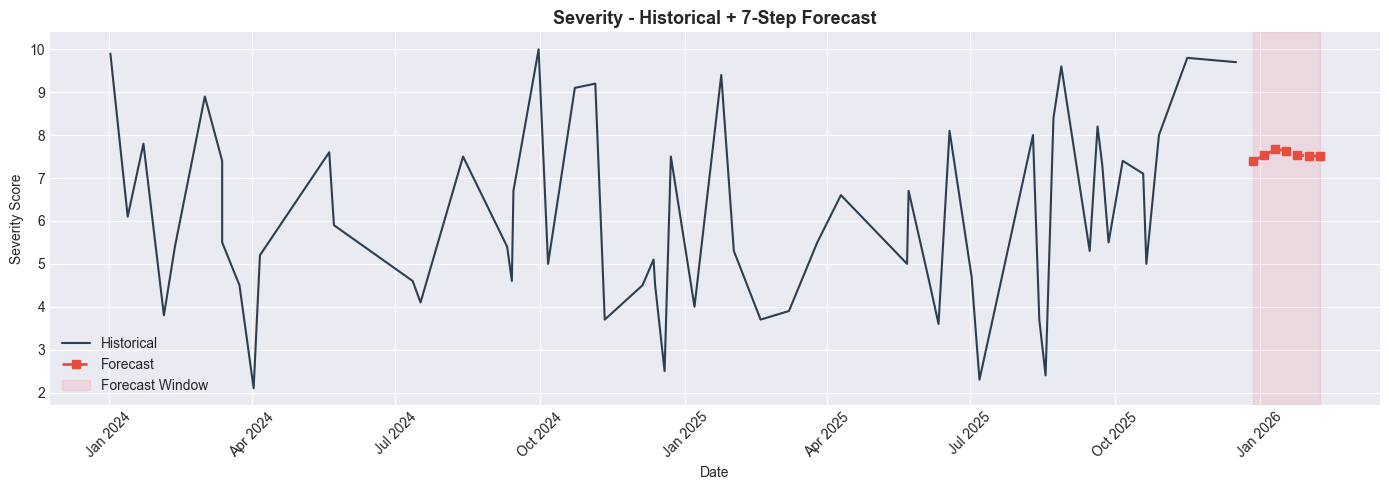

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['start_time'], df[TARGET], color='#2c3e50', linewidth=1.5, label='Historical')
ax.plot(future_df['date'], future_df['predicted_severity'],
        color='#e74c3c', linewidth=2, linestyle='--', marker='s', markersize=6, label='Forecast')
ax.axvspan(future_df['date'].iloc[0], future_df['date'].iloc[-1],
           alpha=0.08, color='red', label='Forecast Window')
ax.set_title('Severity - Historical + 7-Step Forecast', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Severity Score')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150)
plt.show()

In [20]:
os.makedirs('outputs', exist_ok=True)

test_start_idx = split + WINDOW
test_dates_idx = df['start_time'].iloc[test_start_idx : test_start_idx + len(y_test_actual)].values

results_df = pd.DataFrame({
    'date'              : test_dates_idx,
    'actual_severity'   : y_test_actual.flatten(),
    'predicted_severity': test_pred_actual.flatten(),
    'baseline_severity' : baseline_preds.flatten()
})
results_df.to_csv('outputs/ai013_test_predictions.csv', index=False)
print('saved → outputs/ai013_test_predictions.csv')
print(results_df.round(3).to_string(index=False))

saved → outputs/ai013_test_predictions.csv
      date  actual_severity  predicted_severity  baseline_severity
2025-08-28              9.6               6.389               5.54
2025-09-15              5.3               6.616               4.66
2025-09-20              8.2               6.485               5.34
2025-09-23              7.3               6.764               5.36
2025-09-27              5.5               6.938               4.22
2025-10-06              7.4               6.838               4.96
2025-10-19              7.1               6.598               6.42
2025-10-21              5.0               6.516               5.88
2025-10-29              8.0               6.170               6.78
2025-11-16              9.8               6.649               7.76
2025-12-17              9.7               7.133               7.18


---
## Step 5 - Analyse Trend Behaviour

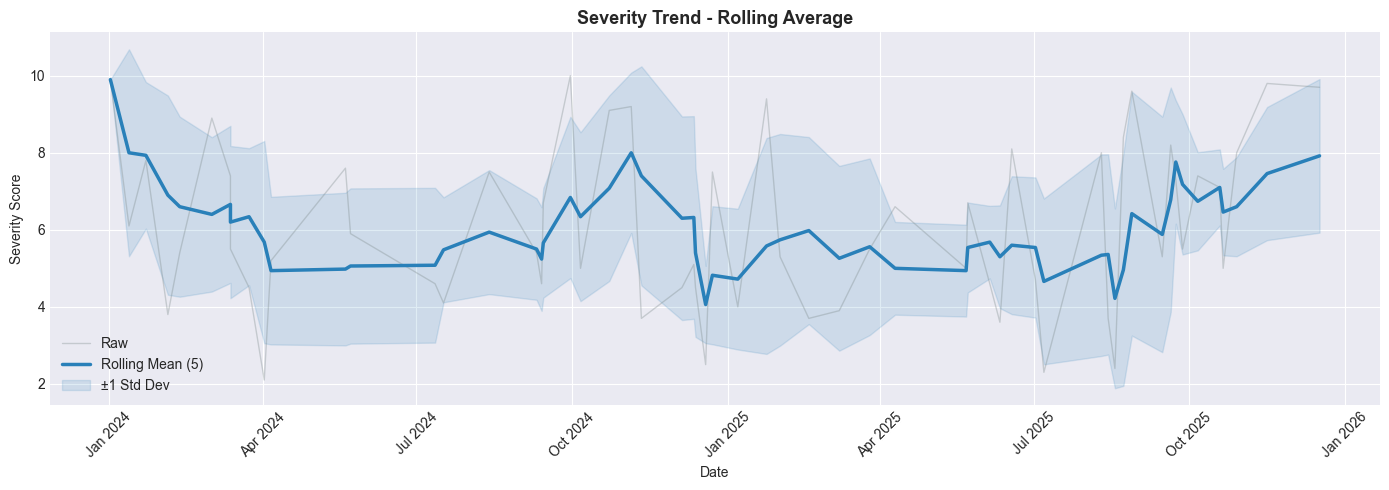

In [21]:
df['rolling_mean'] = df[TARGET].rolling(window=5, min_periods=1).mean()
df['rolling_std']  = df[TARGET].rolling(window=5, min_periods=1).std().fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['start_time'], df[TARGET], alpha=0.35, color='#7f8c8d', linewidth=1, label='Raw')
ax.plot(df['start_time'], df['rolling_mean'], color='#2980b9', linewidth=2.5, label='Rolling Mean (5)')
ax.fill_between(df['start_time'],
                df['rolling_mean'] - df['rolling_std'],
                df['rolling_mean'] + df['rolling_std'],
                alpha=0.15, color='#2980b9', label='±1 Std Dev')
ax.set_title('Severity Trend - Rolling Average', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Severity Score')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('trend_rolling.png', dpi=150)
plt.show()

In [22]:
df['trend_dir'] = df['rolling_mean'].diff().apply(
    lambda x: 'Rising' if x > 0 else ('Declining' if x < 0 else 'Stable')
)
print(df['trend_dir'].value_counts())

trend_dir
Rising       30
Declining    27
Stable        1
Name: count, dtype: int64


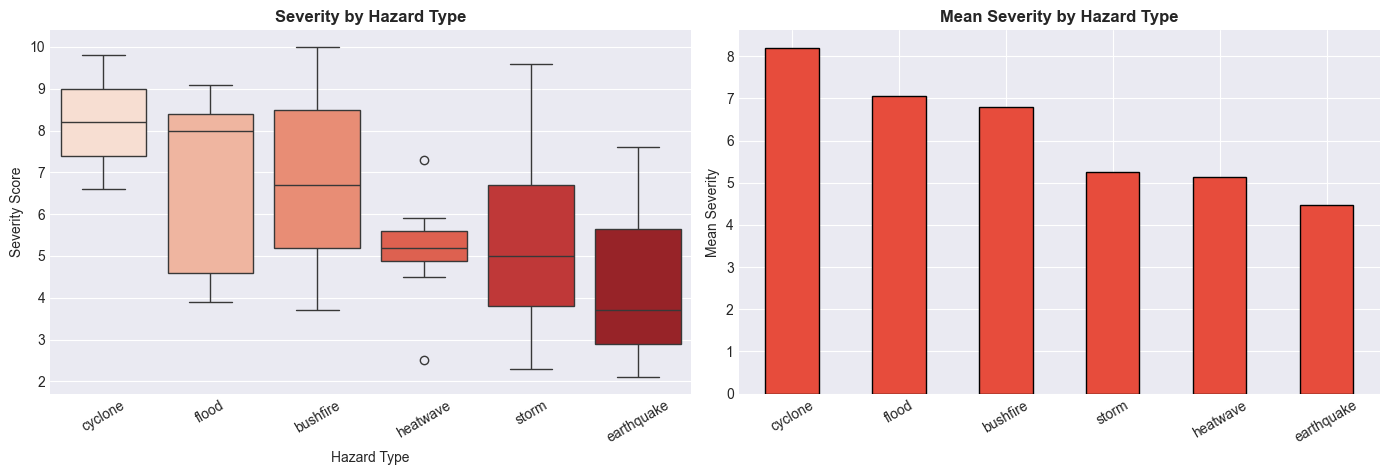

In [23]:
# severity by hazard type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hazard_order = df.groupby('event_type')[TARGET].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df, x='event_type', y=TARGET, order=hazard_order, ax=axes[0], palette='Reds')
axes[0].set_title('Severity by Hazard Type', fontweight='bold')
axes[0].set_xlabel('Hazard Type')
axes[0].set_ylabel('Severity Score')
axes[0].tick_params(axis='x', rotation=30)

mean_per_type = df.groupby('event_type')[TARGET].mean().sort_values(ascending=False)
mean_per_type.plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Mean Severity by Hazard Type', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Severity')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('')
plt.tight_layout()
plt.savefig('severity_by_hazard_type.png', dpi=150)
plt.show()

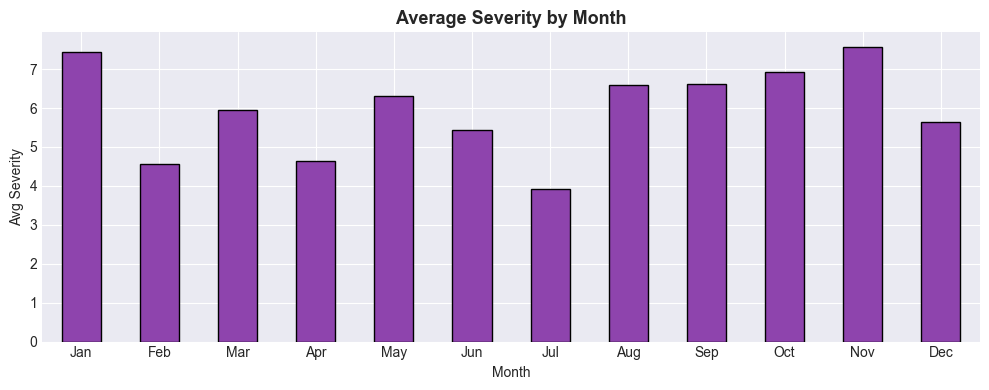

In [24]:
# monthly pattern - any seasonal spikes?
df['month'] = df['start_time'].dt.month
monthly_avg  = df.groupby('month')[TARGET].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
monthly_avg.plot(kind='bar', ax=ax, color='#8e44ad', edgecolor='black')
ax.set_title('Average Severity by Month', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Severity')
ax.set_xticklabels([month_labels[m - 1] for m in monthly_avg.index], rotation=0)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

                    mean   max  count
state                                
Western Australia   7.72   9.9      9
Queensland          6.46   9.1      8
Northern Territory  5.98   7.6      4
New South Wales     5.95   9.7      8
Victoria            5.71   9.6     17
Tasmania            5.52  10.0      9
South Australia     4.50   8.9      3


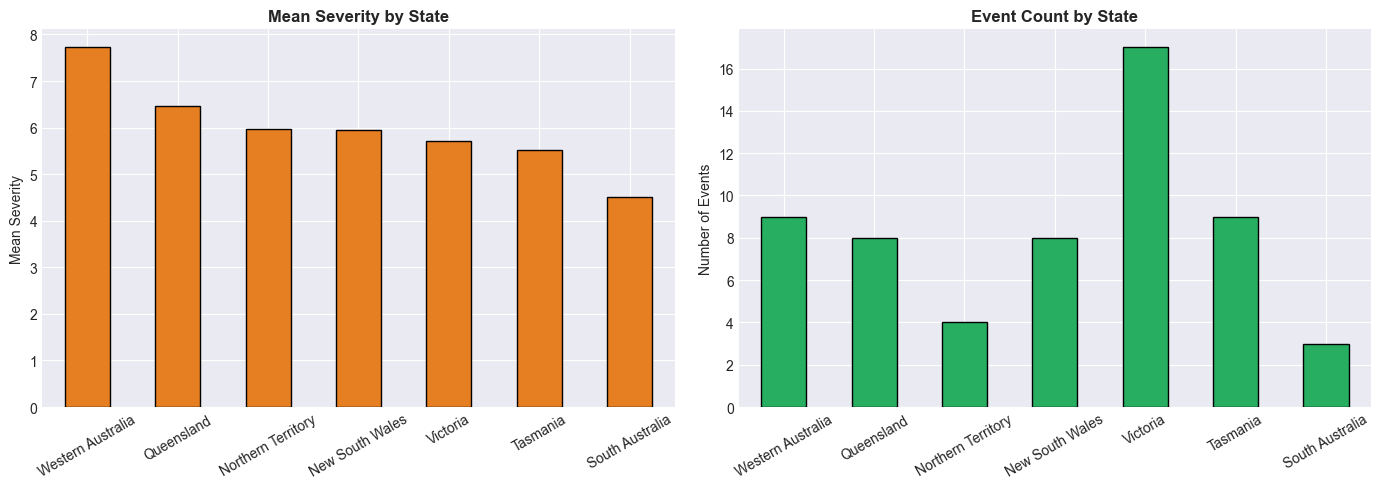

In [25]:
# severity by state - see which regions are hit hardest
region_stats = df.groupby('state')[TARGET].agg(['mean', 'max', 'count']).sort_values('mean', ascending=False)
print(region_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_stats['mean'].plot(kind='bar', ax=axes[0], color='#e67e22', edgecolor='black')
axes[0].set_title('Mean Severity by State', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Severity')
axes[0].tick_params(axis='x', rotation=30)

region_stats['count'].plot(kind='bar', ax=axes[1], color='#27ae60', edgecolor='black')
axes[1].set_title('Event Count by State', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Events')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('severity_by_state.png', dpi=150)
plt.show()

---
## Step 6 - Compare Predictions vs Actual

In [26]:
mae_lstm  = mean_absolute_error(y_test_actual, test_pred_actual)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, test_pred_actual))
r2_lstm   = r2_score(y_test_actual, test_pred_actual)

mae_base  = mean_absolute_error(y_test_actual, baseline_preds)
rmse_base = np.sqrt(mean_squared_error(y_test_actual, baseline_preds))
r2_base   = r2_score(y_test_actual, baseline_preds)

print(f'{"":<20} {"LSTM":>10} {"Baseline":>10}')
print('-' * 42)
print(f'{"MAE":<20} {mae_lstm:>10.4f} {mae_base:>10.4f}')
print(f'{"RMSE":<20} {rmse_lstm:>10.4f} {rmse_base:>10.4f}')
print(f'{"R2":<20} {r2_lstm:>10.4f} {r2_base:>10.4f}')
print()
better = 'LSTM' if mae_lstm < mae_base else 'Baseline'
print(f'Lower MAE: {better}')

                           LSTM   Baseline
------------------------------------------
MAE                      1.6677     1.8691
RMSE                     1.9088     2.1249
R2                      -0.3112    -0.6249

Lower MAE: LSTM


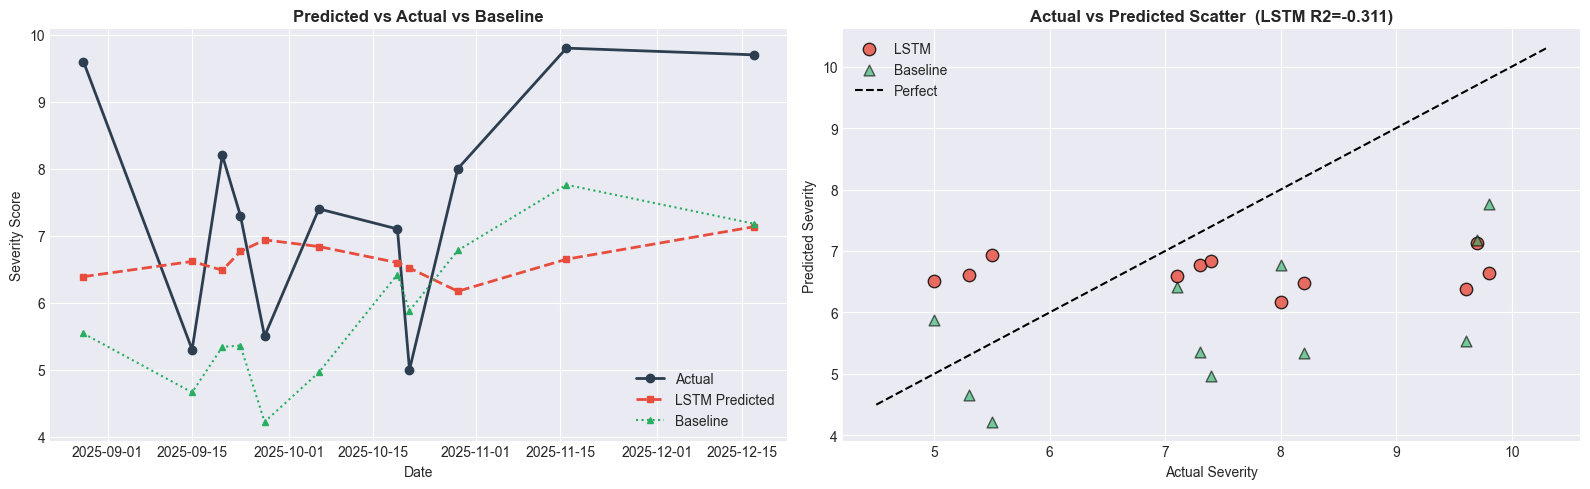

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(test_dates_idx, y_test_actual,
             color='#2c3e50', linewidth=2, marker='o', markersize=6, label='Actual')
axes[0].plot(test_dates_idx, test_pred_actual,
             color='#e74c3c', linewidth=2, linestyle='--', marker='s', markersize=5, label='LSTM Predicted')
axes[0].plot(test_dates_idx, baseline_preds,
             color='#27ae60', linewidth=1.5, linestyle=':', marker='^', markersize=5, label='Baseline')
axes[0].set_title('Predicted vs Actual vs Baseline', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Severity Score')
axes[0].legend()

lo = min(y_test_actual.min(), test_pred_actual.min()) - 0.5
hi = max(y_test_actual.max(), test_pred_actual.max()) + 0.5
axes[1].scatter(y_test_actual, test_pred_actual,
                color='#e74c3c', alpha=0.8, edgecolors='black', s=80, label='LSTM')
axes[1].scatter(y_test_actual, baseline_preds,
                color='#27ae60', alpha=0.6, edgecolors='black', s=60, marker='^', label='Baseline')
axes[1].plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Perfect')
axes[1].set_title(f'Actual vs Predicted Scatter  (LSTM R2={r2_lstm:.3f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Severity')
axes[1].set_ylabel('Predicted Severity')
axes[1].legend()

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150)
plt.show()

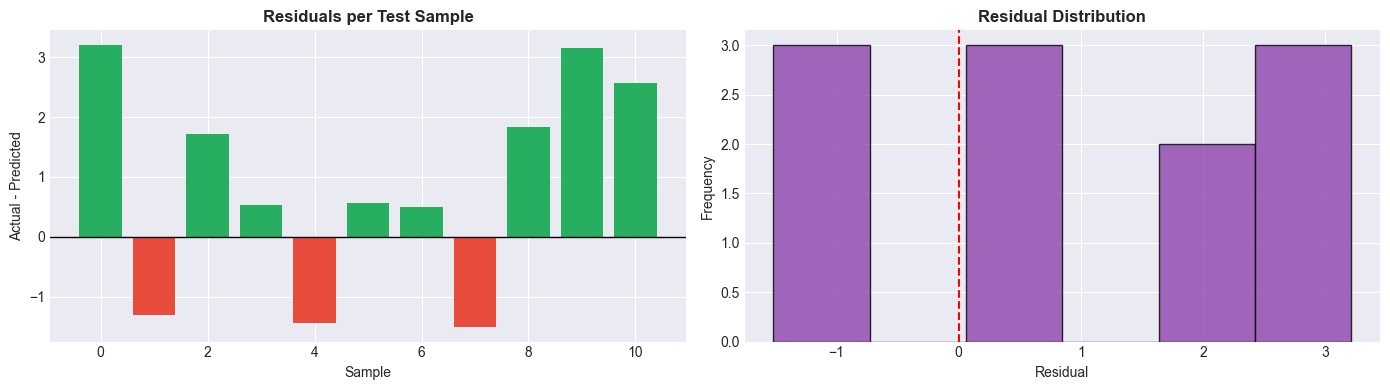

mean residual: 0.891  (close to 0 = no systematic bias)


In [28]:
residuals = y_test_actual.flatten() - test_pred_actual.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(residuals)), residuals,
            color=['#27ae60' if r >= 0 else '#e74c3c' for r in residuals])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Residuals per Test Sample', fontweight='bold')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Actual - Predicted')

axes[1].hist(residuals, bins=6, color='#8e44ad', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('residuals.png', dpi=150)
plt.show()

print(f'mean residual: {residuals.mean():.3f}  (close to 0 = no systematic bias)')

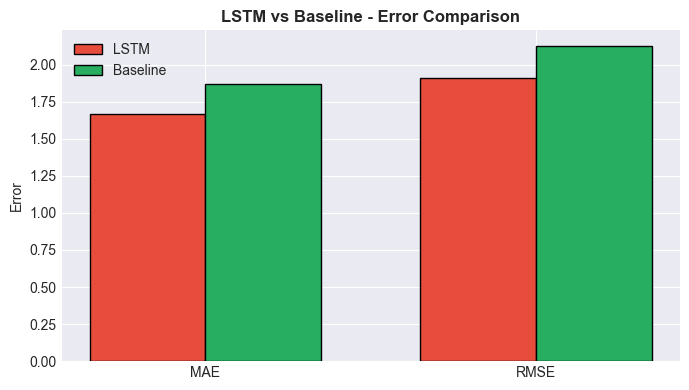

In [29]:
metrics   = ['MAE', 'RMSE']
lstm_vals = [mae_lstm, rmse_lstm]
base_vals = [mae_base, rmse_base]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, lstm_vals, w, label='LSTM',     color='#e74c3c', edgecolor='black')
ax.bar(x + w/2, base_vals, w, label='Baseline', color='#27ae60', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('LSTM vs Baseline - Error Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Error')
ax.legend()
plt.tight_layout()
plt.savefig('model_vs_baseline.png', dpi=150)
plt.show()